# 🏆 Part 3: The Neural Network Championship (CIFAR-10)

In the previous parts, we worked with simple regression and binary classification. Now, we face a real Challenge.

**The Task:** Classify colored images from the **CIFAR-10** dataset using only **Multi-Layer Perceptrons (MLP)**.

> **Constraint:** You are **NOT** allowed to use Convolutional Layers (CNNs) yet. You must push the limits of Linear Layers (`nn.Linear`).

### The Dataset: CIFAR-10
* **Images:** $32 \times 32$ pixels, Colored (3 Channels: Red, Green, Blue).
* **Input Size:** $32 \times 32 \times 3 = 3072$ values per image.
* **Classes (10):** Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck.

### The Rules:
1. **Strict Split:** We use Train (to learn), Validation (to tune), and Test (final exam).
2. **Architecture:** You design the model. How deep? How wide? Which activation?
3. **Robustness:** At the end, we will run a **Stress Test** to see if your model can recognize objects when they are moved to the corners of the image.

---

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
import glob
from datetime import datetime
from tqdm.notebook import tqdm

# 1. Setup Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Device: {device}")

# 2. Fix Random Seed (for reproducibility)
SEED = 42
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

✅ Device: cpu


## 1. Data Preparation

We need to normalize the RGB images. A common range is $[-1, 1]$.
We calculate: `input = (image - 0.5) / 0.5`.

In [3]:
# --- TRANSFORMATIONS ---
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) # Normalize 3 channels
])

# --- LOAD DATASETS ---
print("⏳ Downloading/Loading CIFAR-10...")
try:
    full_train_set = torchvision.datasets.CIFAR10(root='../Datasets', train=True, download=True, transform=transform)
    test_set = torchvision.datasets.CIFAR10(root='../Datasets', train=False, download=True, transform=transform)
except:
    print("⚠️ Error loading data. Make sure internet is active or path is correct.")

# --- SPLIT TRAIN / VAL ---
# 80% Training, 20% Validation
train_size = int(0.8 * len(full_train_set))
val_size = len(full_train_set) - train_size
train_set, val_set = torch.utils.data.random_split(full_train_set, [train_size, val_size])

# --- DATALOADERS ---
BATCH_SIZE = 128
train_loader = torch.utils.data.DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

print(f"\n✅ Data Ready:")
print(f"   - Training Set:   {len(train_set)} images")
print(f"   - Validation Set: {len(val_set)} images")
print(f"   - Test Set:       {len(test_set)} images")
print(f"   - Input Shape:    3 channels x 32 x 32 = 3072 features")

⏳ Downloading/Loading CIFAR-10...
Files already downloaded and verified
Files already downloaded and verified

✅ Data Ready:
   - Training Set:   40000 images
   - Validation Set: 10000 images
   - Test Set:       10000 images
   - Input Shape:    3 channels x 32 x 32 = 3072 features


## 2. Design Your Architecture

Since inputs are images, the first layer must **Flatten** the 3D tensor $(3, 32, 32)$ into a 1D vector $(3072)$.

### Baseline Model
A simple starting point.

In [4]:
class BaselineModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Flatten(),                 # 1. Flatten image to vector (size 3072)
            nn.Linear(3072, 512),         # 2. Hidden Layer 1
            nn.ReLU(),
            nn.Linear(512, 64),           # 3. Hidden Layer 2
            nn.ReLU(),
            nn.Linear(64, 10)             # 4. Output Layer (10 classes)
        )

    def forward(self, x):
        return self.layers(x)

### 🛠️ Your Competitor Model
Modify this class! Try to beat the baseline.
**Tips:**
* **Deeper:** Add more layers.
* **Wider:** Increase neuron count (e.g., 1024, 2048).
* **Regularization:** Use `nn.Dropout(p=0.2)` to prevent memorization.
* **Activations:** Try `nn.LeakyReLU()`.

In [6]:
class MyCompetitorModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Flatten(),
            
            # --- ARCHITECTURE START ---
            nn.Linear(3072, 1024),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            nn.Linear(512, 128),
            nn.ReLU(),
            # --- ARCHITECTURE END ---
            
            nn.Linear(128, 10) # Output (Always 10)
        )

    def forward(self, x):
        return self.layers(x)

# Bonus: A Fusion Model (Branching Network)
class FusionModel(nn.Module):
    def __init__(self):
        super().__init__()
        # Branch 1: Wide but shallow
        self.branch_wide = nn.Sequential(
            nn.Flatten(),
            nn.Linear(3072, 1024),
            nn.LeakyReLU(),
            nn.Dropout(0.3),
            nn.Linear(1024, 64),
            nn.LeakyReLU()
        )
        # Branch 2: Narrow but deep
        self.branch_deep = nn.Sequential(
            nn.Flatten(),
            nn.Linear(3072, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU()
        )
        # Combine
        self.classifier = nn.Linear(64 + 32, 10)

    def forward(self, x):
        out1 = self.branch_wide(x)
        out2 = self.branch_deep(x)
        combined = torch.cat([out1, out2], dim=1)
        return self.classifier(combined)

## 3. The Training Engine 🚂

This function handles the entire lifecycle:
1. Creates a unique folder.
2. Trains and Validates.
3. Saves logs to `log.csv`.
4. Saves the best model weights.

In [7]:
def train_competitor(model_class, epochs=10, lr=0.001):
    # 1. Setup Directories
    timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
    model_name = model_class.__name__
    save_dir = f"models/{model_name}_{timestamp}"
    os.makedirs(save_dir, exist_ok=True)
    
    print(f"\n🥊 STARTING TRAINING: {model_name}")
    print(f"📂 Saving results to: {save_dir}")
    
    # 2. Init Model
    model = model_class().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    # 3. Log File
    log_path = f"{save_dir}/log.csv"
    with open(log_path, "w") as f:
        f.write("epoch,train_loss,val_loss,val_acc\n")
        
    best_acc = 0.0
    
    # --- EPOCH LOOP ---
    for epoch in range(epochs):
        # A. TRAIN
        model.train()
        train_loss = 0.0
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", unit="batch")
        
        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            output = model(images)
            loss = criterion(output, labels)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            pbar.set_postfix(loss=loss.item())
            
        avg_train_loss = train_loss / len(train_loader)
        
        # B. VALIDATE
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                output = model(images)
                v_loss = criterion(output, labels)
                val_loss += v_loss.item()
                
                _, predicted = torch.max(output.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        
        avg_val_loss = val_loss / len(val_loader)
        val_acc = 100 * correct / total
        
        # Update pbar
        pbar.set_postfix(train_loss=f"{avg_train_loss:.4f}", val_acc=f"{val_acc:.2f}%")
        
        # C. LOGGING
        with open(log_path, "a") as f:
            f.write(f"{epoch+1},{avg_train_loss:.4f},{avg_val_loss:.4f},{val_acc:.2f}\n")
            
        # D. SAVE CHECKPOINTS
        torch.save(model.state_dict(), f"{save_dir}/current_model.pth")
        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), f"{save_dir}/best_model.pth")
            
    print(f"🏆 Training Finished! Best Validation Acc: {best_acc:.2f}%")
    
    # --- FINAL TEST EVALUATION ---
    print("🔍 Running final evaluation on TEST set...")
    
    def evaluate_ckpt(path):
        m = model_class().to(device)
        checkpoint = torch.load(path, weights_only=True)
        m.load_state_dict(checkpoint)
        m.eval()
        corr = 0
        tot = 0
        with torch.no_grad():
            for imgs, lbls in test_loader:
                imgs, lbls = imgs.to(device), lbls.to(device)
                out = m(imgs)
                _, pred = torch.max(out.data, 1)
                tot += lbls.size(0)
                corr += (pred == lbls).sum().item()
        return 100 * corr / tot

    final_test_acc = evaluate_ckpt(f"{save_dir}/best_model.pth")
    print(f"✅ Final Test Accuracy (Best Model): {final_test_acc:.2f}%")
    
    # Save test result
    with open(f"{save_dir}/test_results.csv", "w") as f:
        f.write("model_version,test_acc\n")
        f.write(f"best_model,{final_test_acc:.4f}\n")
    
    # Plot
    try:
        df = pd.read_csv(log_path)
        plt.figure(figsize=(10, 4))
        plt.subplot(1, 2, 1)
        plt.plot(df['epoch'], df['train_loss'], label='Train Loss')
        plt.plot(df['epoch'], df['val_loss'], label='Val Loss')
        plt.legend()
        plt.title('Loss History')
        
        plt.subplot(1, 2, 2)
        plt.plot(df['epoch'], df['val_acc'], color='green', marker='o')
        plt.title('Validation Accuracy')
        plt.savefig(f"{save_dir}/training_plot.png")
        plt.show()
    except Exception as e:
        print(f"Plotting error: {e}")

### 🏁 Start the Competition!
Run the cells below to train your fighters.


🥊 STARTING TRAINING: BaselineModel
📂 Saving results to: models/BaselineModel_2026-02-19_16-00-21


Epoch 1/10:   0%|          | 0/313 [00:00<?, ?batch/s]

Epoch 2/10:   0%|          | 0/313 [00:00<?, ?batch/s]

Epoch 3/10:   0%|          | 0/313 [00:00<?, ?batch/s]

Epoch 4/10:   0%|          | 0/313 [00:00<?, ?batch/s]

...

Epoch 7/10:   0%|          | 0/313 [00:00<?, ?batch/s]

Epoch 8/10:   0%|          | 0/313 [00:00<?, ?batch/s]

Epoch 9/10:   0%|          | 0/313 [00:00<?, ?batch/s]

Epoch 10/10:   0%|          | 0/313 [00:00<?, ?batch/s]

🏆 Training Finished! Best Validation Acc: 53.74%
🔍 Running final evaluation on TEST set...
✅ Final Test Accuracy (Best Model): 52.66%


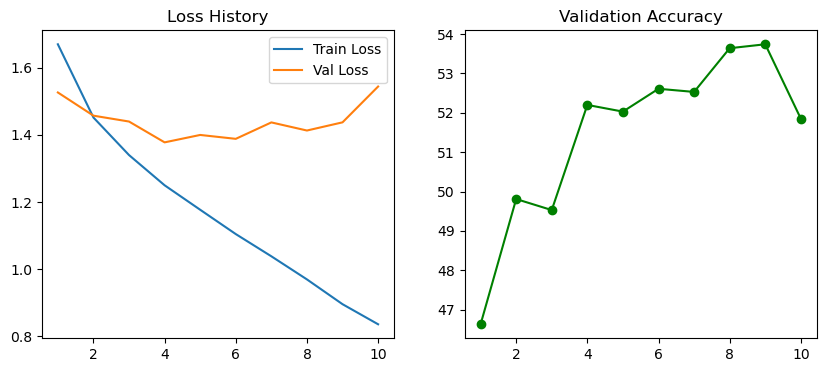


🥊 STARTING TRAINING: MyCompetitorModel
📂 Saving results to: models/MyCompetitorModel_2026-02-19_16-10-11


Epoch 1/10:   0%|          | 0/313 [00:00<?, ?batch/s]

Epoch 2/10:   0%|          | 0/313 [00:00<?, ?batch/s]

Epoch 3/10:   0%|          | 0/313 [00:00<?, ?batch/s]

Epoch 4/10:   0%|          | 0/313 [00:00<?, ?batch/s]

...

Epoch 7/10:   0%|          | 0/313 [00:00<?, ?batch/s]

Epoch 8/10:   0%|          | 0/313 [00:00<?, ?batch/s]

Epoch 9/10:   0%|          | 0/313 [00:00<?, ?batch/s]

Epoch 10/10:   0%|          | 0/313 [00:00<?, ?batch/s]

🏆 Training Finished! Best Validation Acc: 54.07%
🔍 Running final evaluation on TEST set...
✅ Final Test Accuracy (Best Model): 53.84%


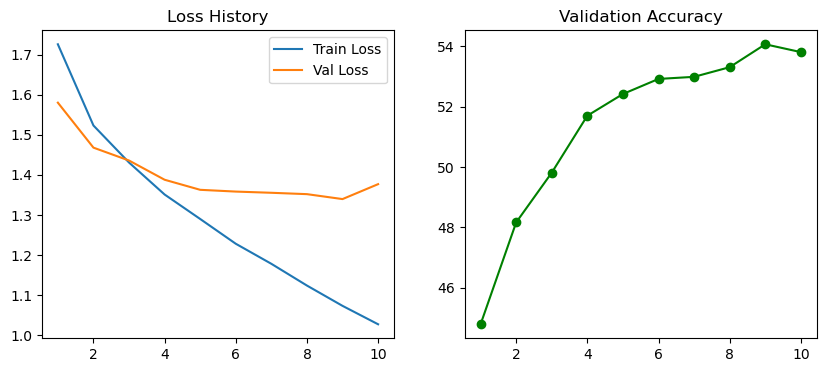


🥊 STARTING TRAINING: FusionModel
📂 Saving results to: models/FusionModel_2026-02-19_16-22-06


Epoch 1/10:   0%|          | 0/313 [00:00<?, ?batch/s]

Epoch 2/10:   0%|          | 0/313 [00:00<?, ?batch/s]

Epoch 3/10:   0%|          | 0/313 [00:00<?, ?batch/s]

Epoch 4/10:   0%|          | 0/313 [00:00<?, ?batch/s]

...

Epoch 7/10:   0%|          | 0/313 [00:00<?, ?batch/s]

Epoch 8/10:   0%|          | 0/313 [00:00<?, ?batch/s]

Epoch 9/10:   0%|          | 0/313 [00:00<?, ?batch/s]

Epoch 10/10:   0%|          | 0/313 [00:00<?, ?batch/s]

🏆 Training Finished! Best Validation Acc: 53.23%
🔍 Running final evaluation on TEST set...
✅ Final Test Accuracy (Best Model): 52.51%


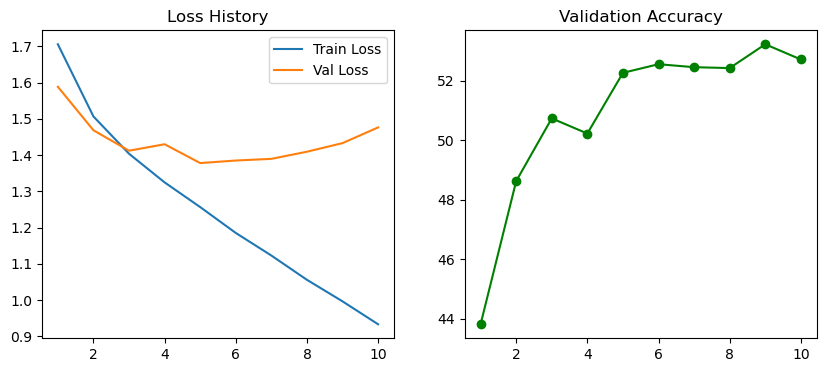

In [8]:
# 1. Baseline
train_competitor(BaselineModel, epochs=10, lr=0.001)

# 2. Your Model
train_competitor(MyCompetitorModel, epochs=10, lr=0.001)

# 3. Fusion Model
train_competitor(FusionModel, epochs=10, lr=0.001)

## 4. The Leaderboard 🏅

Who won? Let's aggregate the results.

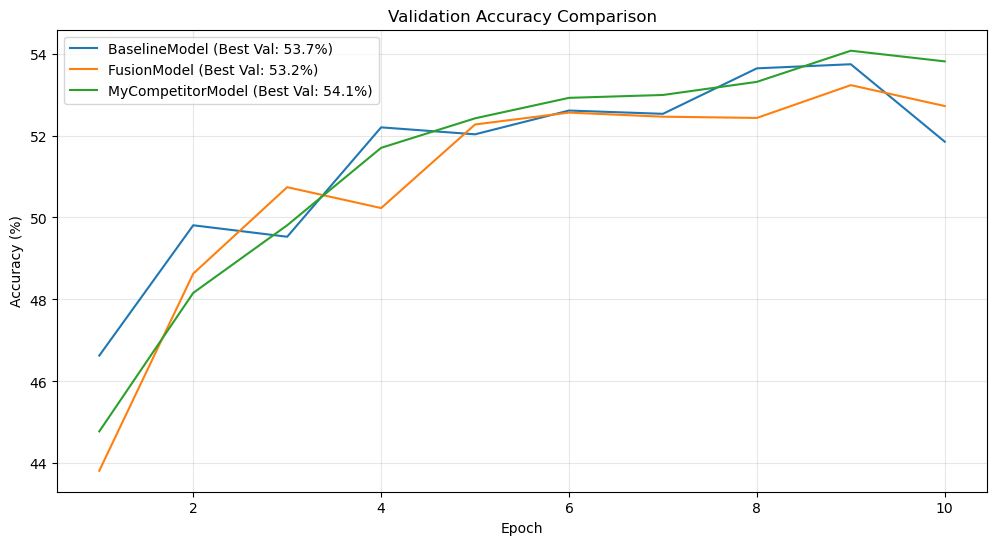


🏅 FINAL LEADERBOARD:


,Model,Test Acc,Val Acc
1,MyCompetitorModel,53.84,54.07
2,BaselineModel,52.66,53.74
3,FusionModel,52.51,53.23


In [9]:
def show_leaderboard():
    log_files = glob.glob("models/*/log.csv")
    results = []
    
    plt.figure(figsize=(12, 6))
    
    for log_file in log_files:
        folder = os.path.dirname(log_file)
        model_name = os.path.basename(folder).split('_20')[0]
        
        try:
            # Load Training History
            df = pd.read_csv(log_file)
            best_val = df['val_acc'].max()
            plt.plot(df['epoch'], df['val_acc'], label=f"{model_name} (Best Val: {best_val:.1f}%)")
            
            # Load Test Result
            test_acc = 0.0
            test_res_path = os.path.join(folder, "test_results.csv")
            if os.path.exists(test_res_path):
                df_t = pd.read_csv(test_res_path)
                test_acc = df_t['test_acc'].values[0]
            
            results.append({
                "Model": model_name,
                "Val Acc": best_val,
                "Test Acc": test_acc,
                "Folder": folder
            })
        except Exception as e:
            print(f"⚠️ Error reading {model_name}: {e}")

    plt.title("Validation Accuracy Comparison")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    # Create Table
    leaderboard_df = pd.DataFrame(results).sort_values(by="Test Acc", ascending=False).reset_index(drop=True)
    leaderboard_df.index += 1
    
    print("\n🏅 FINAL LEADERBOARD:")
    display(leaderboard_df[['Model', 'Test Acc', 'Val Acc']])
    return leaderboard_df

leaderboard = show_leaderboard()

## 5. The Stress Test: Corner Robustness 💥

This is the most important part of the lesson. We will test if your MLP really "sees" the object, or just memorizes pixels.

**The Test:**
1. Take a Test image ($32 \times 32$).
2. Shrink it to $16 \times 16$.
3. Paste it into the **4 corners** of a black background.
4. Ask the model to classify it.

**Hypothesis:** MLPs are NOT "translation invariant". If you move the cat to the corner, the MLP should fail. (CNNs will solve this later!).


🧪 RUNNING STRESS TEST (Corner Robustness)...


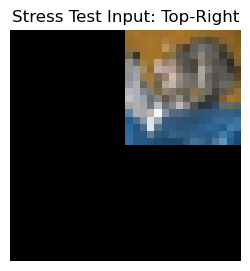

C:\Users\jom_j\AppData\Local\Temp\ipykernel_5656\4180185660.py:48: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f"{row['Folder']}/best_mode


💥 STRESS TEST RESULTS (Corner Robustness):


,Model,Original,Top-Left,Top-Right,Bottom-Left,Bottom-Right,Corner AVG
0,MyCompetitorModel,56.0,15.0,10.1,11.8,11.7,12.2
2,FusionModel,55.2,13.4,14.1,10.4,10.8,12.2
1,BaselineModel,55.1,10.4,10.7,12.0,14.5,11.9


In [12]:
def run_stress_test(leaderboard_df):
    print("\n🧪 RUNNING STRESS TEST (Corner Robustness)...")
    
    # 1. Prepare Batch (1000 images)
    loader = torch.utils.data.DataLoader(test_set, batch_size=1000, shuffle=False)
    images, labels = next(iter(loader))
    
    # 2. Create Variants
    B, C, H, W = images.shape
    small_h, small_w = 16, 16
    
    # Resize images to 16x16
    small_imgs = F.interpolate(images, size=(small_h, small_w), mode='bilinear', align_corners=False)
    
    variants = {"Original": images}
    corners = {
        "Top-Left":     (0, small_h, 0, small_w),
        "Top-Right":    (0, small_h, small_w, W),
        "Bottom-Left":  (small_h, H, 0, small_w),
        "Bottom-Right": (small_h, H, small_w, W),
    }
    
    for name, (y1, y2, x1, x2) in corners.items():
        # Create black canvas (-1.0 in normalized space)
        canvas = torch.full_like(images, -1.0)
        canvas[:, :, y1:y2, x1:x2] = small_imgs
        variants[name] = canvas
        
    # 3. Visualize one example
    ex_img = variants['Top-Right'][0].permute(1, 2, 0) * 0.5 + 0.5
    plt.figure(figsize=(3,3))
    plt.imshow(ex_img)
    plt.title("Stress Test Input: Top-Right")
    plt.axis('off')
    plt.show()

    # 4. Evaluate Models
    stress_results = []
    
    for _, row in leaderboard_df.iterrows():
        model_name = row['Model']
        
        # Dynamic class loading
        if model_name not in globals(): continue
        
        try:
            model = globals()[model_name]().to(device)
            model.load_state_dict(torch.load(f"{row['Folder']}/best_model.pth", map_location=device))
            model.eval()
        except:
            print(f"⚠️ Could not load {model_name}")
            continue
        
        res = {"Model": model_name}
        avg_score = 0
        
        with torch.no_grad():
            for v_name, v_imgs in variants.items():
                v_imgs = v_imgs.to(device)
                outputs = model(v_imgs)
                _, preds = torch.max(outputs, 1)
                
                acc = (preds.cpu() == labels).float().mean().item() * 100
                res[v_name] = round(acc, 1)
                
                if v_name != "Original": # Only count corners for stress score
                    avg_score += acc
        
        res["Corner AVG"] = round(avg_score / 4, 1)
        stress_results.append(res)
        
    # 5. Show Results
    df_stress = pd.DataFrame(stress_results).sort_values(by="Corner AVG", ascending=False)
    print("\n💥 STRESS TEST RESULTS (Corner Robustness):")
    display(df_stress)

run_stress_test(leaderboard)